##Setup

###Installs

In [1]:
!pip install kaggle

In [2]:
!pip install gensim

In [3]:
!pip -q install datasets pandas

###Imports

In [4]:
import kagglehub
import pandas as pd
import os
from gensim.models import Word2Vec
from datasets import load_dataset
import numpy as np
import seaborn as sns

##Load Dataset

In [5]:
ds = load_dataset("sentence-transformers/eli5", split="train[:5000]")

df = ds.to_pandas()
df = df[["question","answer"]]

df.head()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


,question,answer
0,in football whats the point of wasting the fir...,"Keep the defense honest, get a feel for the pa..."
1,Why are different tiers (regular < mid < premi...,"As someone who uses quality Premium, I wish th..."
2,Stars and Visibility,It's a quirk of the human eye. At the center o...
3,How do we know all the money the government is...,I'm pretty confident most of it isn't going ba...
4,What are good and bad sides of manual and auto...,"Automatics weigh more, so that alone makes gas..."


In [6]:
df.head()

,question,answer
0,in football whats the point of wasting the fir...,"Keep the defense honest, get a feel for the pa..."
1,Why are different tiers (regular < mid < premi...,"As someone who uses quality Premium, I wish th..."
2,Stars and Visibility,It's a quirk of the human eye. At the center o...
3,How do we know all the money the government is...,I'm pretty confident most of it isn't going ba...
4,What are good and bad sides of manual and auto...,"Automatics weigh more, so that alone makes gas..."


In [7]:
df["question"][5]

'How do muscles grow?'

## Word2Vec Embeddings



###Embedding data Handeling

In [8]:
questions = df["question"].str.lower().str.split().tolist()
answers = df["answer"].str.lower().str.split().tolist()

In [9]:
all_possible_sentences = questions+answers+[["END_OF_SENTENCE"]]

In [10]:
embeder = Word2Vec(all_possible_sentences, vector_size=100, window=5, min_count=1)

print(embeder.wv["dog"])

[-0.08541307  0.23886418 -0.15209153 -0.0544007  -0.17734002 -0.26549464
  0.05083689  0.34380084  0.00345031  0.00853102 -0.20725769 -0.21851352
  0.02058675  0.16778536 -0.02305573 -0.11061104  0.3081846  -0.11819552
 -0.0540576  -0.34557134  0.30605635  0.08755375  0.45531958  0.00203316
  0.05147558 -0.07818304 -0.31732324 -0.25129318  0.04588381  0.13376515
  0.28817984  0.10924482  0.16984421 -0.3636626  -0.04665422  0.35686037
  0.04415117 -0.06123921 -0.22932859 -0.34779853 -0.16565888 -0.12737642
  0.10506475 -0.10594985  0.14346828 -0.16753389 -0.20587277 -0.14531931
  0.13881238  0.05675595  0.14899246 -0.22709502 -0.26608378 -0.15671623
  0.06819847 -0.08652159  0.09108167 -0.18854125 -0.14256312  0.09695416
  0.10211445 -0.11599311  0.14394416  0.12860695 -0.03696952  0.13326822
  0.13996178  0.00837178 -0.26269564  0.17704952 -0.10126509 -0.04407023
  0.16446717 -0.06337647  0.12216449  0.05463465  0.04607029  0.06970907
 -0.13381122  0.16196217 -0.11182947 -0.06569093 -0

If word is outside of library we will just treat it as a zero vector

In [11]:
def get_embedding(word, vector_size=100):
    if word in embeder.wv:
        return embeder.wv[word]
    else:
        return np.zeros(vector_size)

I chose word2vec for its ez of use as well as its single word translations. With something like Bert you need the rest of the sentence as context for a given word. For this homework I want to be guessing the next word so it makes the most sence to have destinct vector values for words. Also Word2vecs ability to customize embeding vector size.

In [12]:
filtered_q = []
filtered_a = []

for q, a in zip(questions, answers):
    if len(q) <= 20 and len(a) <= 30:
        a.append("END_OF_SENTENCE")
        filtered_q.append(q)
        filtered_a.append(a)

questions = filtered_q
answers = filtered_a

In [13]:
answers[5]=answers[5][:10]
answers[5].append("END_OF_SENTENCE")

In [14]:
print(answers[5])

['because', 'every', 'state', 'has', 'a', 'different', 'tax', 'rate', 'on', 'goods,', 'END_OF_SENTENCE']


In [15]:
len(questions)

744

In [16]:
questions[5]#most data caters to this question as traintime and data not avalable enough.

['why',
 'is',
 'sales',
 'tax',
 'in',
 'the',
 'us',
 'excluded',
 'from',
 'the',
 'list',
 'price?']

In [17]:
longest = max(questions, key=len)
len(longest)

20

In [18]:
import random
dataSize = 2000
x_questions = []
x_answers = []
y_answers = []
for i in range(dataSize):
  if(random.random()<.3):
    i = random.randint(0, len(questions)-1)
  else:
    i = 5
  q = questions[i]
  a = answers[i]

  cut = random.randint(0, len(a)-1)

  x_question = q
  x_answer = a[:cut]
  y_answer = a[cut]
  x_questions.append(x_question)
  x_answers.append(x_answer)
  y_answers.append(y_answer)

print(x_question)
print(x_answer)
print(y_answer)

['why', 'is', 'sales', 'tax', 'in', 'the', 'us', 'excluded', 'from', 'the', 'list', 'price?']
['because', 'every', 'state', 'has', 'a', 'different', 'tax', 'rate']
on


In [19]:
import random

data = list(zip(x_questions, x_answers, y_answers))

random.shuffle(data)

split = int(0.8 * len(data))  # 80% train

train_data = data[:split]
test_data = data[split:]

xq_train, xa_train, y_train = zip(*train_data)
xq_test, xa_test, y_test = zip(*test_data)

xq_train, xa_train, y_train = list(xq_train), list(xa_train), list(y_train)
xq_test, xa_test, y_test = list(xq_test), list(xa_test), list(y_test)

In [20]:
def vectorize_words(word_list):

    return np.array([get_embedding(w) for w in word_list])

In [21]:
def vectorize_sentences(sentences):

    return [
        [get_embedding(word) for word in sentence]
        for sentence in sentences
    ]

In [22]:
xq_train_vec = vectorize_sentences(xq_train)
xa_train_vec = vectorize_sentences(xa_train)
y_train_vec  = vectorize_words(y_train)

xq_test_vec = vectorize_sentences(xq_test)
xa_test_vec = vectorize_sentences(xa_test)
y_test_vec  = vectorize_words(y_test)

###Word comparison

In [23]:
def cosine_similarity(word_1, word_2):
  a = embeder.wv[word_1]
  b = embeder.wv[word_2]
  return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))

In [24]:
cosine_similarity("pizza", "cat")

np.float32(0.91893196)

In [25]:
def batchpossesing(wordpars):
  similarity = []
  for i in range(len(wordpars)):
    similarity.append(cosine_similarity(wordpars[i][0], wordpars[i][1]))
  return similarity

In [26]:
wordpairs=[["dog", "cat"], ["pizza", "window"], ["america", "canada"], ["lane", "tap"], ["flag", "fridge"]]
batchpossesing(wordpairs)

[np.float32(0.9907872),
 np.float32(0.9073745),
 np.float32(0.98421526),
 np.float32(0.85852224),
 np.float32(0.8803161)]

In [27]:
from sklearn.manifold import TSNE
import numpy as np

words = y_test[:20]
vectors = np.array([embeder.wv[w] for w in words])

coords = TSNE(n_components=2, perplexity=5).fit_transform(vectors)

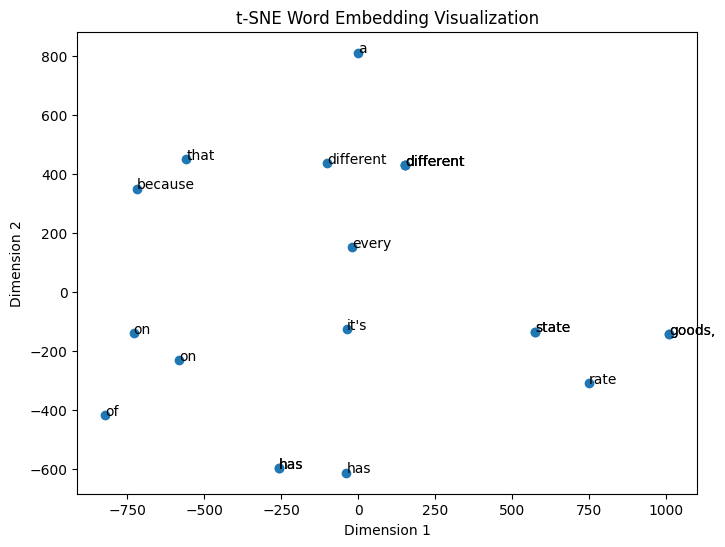

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(coords[:,0], coords[:,1])

for i, word in enumerate(words):
    plt.annotate(word, (coords[i,0], coords[i,1]))

plt.title("t-SNE Word Embedding Visualization")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")

plt.show()

###Euclidian Distance

In [29]:
def euclidian_Distance(word_1, word_2):
  a = embeder.wv[word_1]
  b = embeder.wv[word_2]
  return np.linalg.norm(a - b)

In [30]:
def euclid_batchpossesing(wordpars):
  similarity = []
  for i in range(len(wordpars)):
    similarity.append(euclidian_Distance(wordpars[i][0], wordpars[i][1]))
  return similarity

In [31]:
euclidian_Distance("dog", "cat")

np.float32(0.4450325)

Eclidian distance in my oppinon is prefreble to cosign similarity. The diffrence for words are much more distinct and makes more sence. Like Dog and cat are very close but dog and at are 30X the distance. This makes more sence to me intuitivly and measures simmilarities of words much better.

In [32]:
import numpy as np

def word_distance(word1, word2, metric="cosine"):
    if metric == "cosine":
        return cosine_similarity(word1, word2)

    elif metric == "euclidean":
        return euclidian_Distance(word1, word2) #disimilar

    else:
        raise ValueError("metric must be 'cosine' or 'euclidean'")

In [33]:
word_distance("dog", "cat", "cosine")

np.float32(0.9907872)

In [34]:
word_distance("dog", "cat", "euclidean")

np.float32(0.4450325)

In [35]:
words = ["dog", "tiger", "lion", "apple", "car", "boat", "at", "maybe"]
base_word = "cat"
ranking = sorted(
    [(w, word_distance(w, base_word, "euclidean")) for w in words],
    key=lambda x: x[1],
    reverse=True
)

for word, score in ranking:
    print(f"{base_word} distance from {word}: {score:.4f}")

cat distance from at: 8.6720
cat distance from car: 3.7597
cat distance from maybe: 1.7438
cat distance from tiger: 1.2993
cat distance from lion: 1.2147
cat distance from boat: 0.7314
cat distance from dog: 0.4450
cat distance from apple: 0.3737


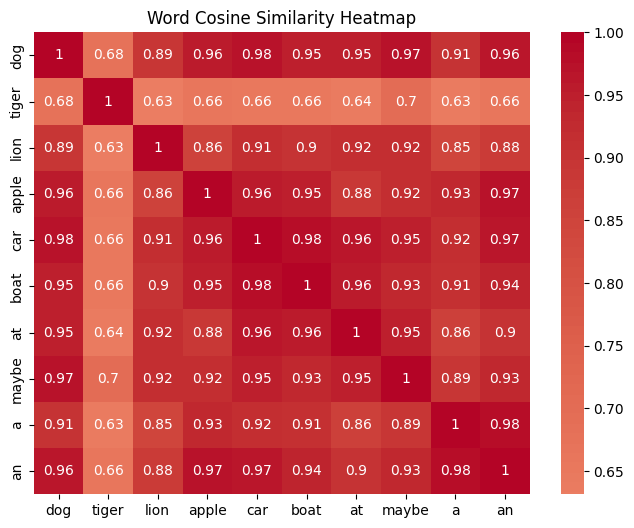

In [36]:
words = ["dog", "tiger", "lion", "apple", "car", "boat", "at", "maybe", "a", "an"]

sim_matrix = np.zeros((len(words), len(words)))

for i, w1 in enumerate(words):
    for j, w2 in enumerate(words):
        sim_matrix[i, j] = word_distance(w1, w2, metric="cosine")

plt.figure(figsize=(8,6))
sns.heatmap(sim_matrix, xticklabels=words, yticklabels=words, annot=True, cmap="coolwarm", center=0)
plt.title("Word Cosine Similarity Heatmap")
plt.show()

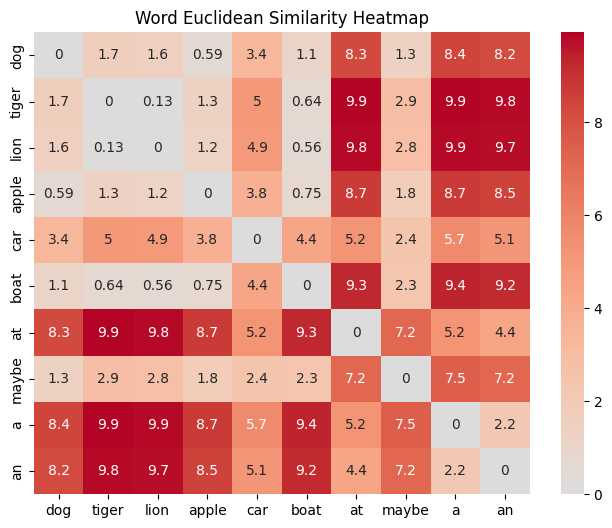

In [37]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

words = ["dog", "tiger", "lion", "apple", "car", "boat", "at", "maybe", "a", "an"]

sim_matrix = np.zeros((len(words), len(words)))

for i, w1 in enumerate(words):
    for j, w2 in enumerate(words):
        sim_matrix[i, j] = word_distance(w1, w2, metric="euclidean")

# plot heatmap
plt.figure(figsize=(8,6))
sns.heatmap(sim_matrix, xticklabels=words, yticklabels=words, annot=True, cmap="coolwarm", center=0)
plt.title("Word Euclidean Similarity Heatmap")
plt.show()

###RNN

A sequencal model is needed for this assignment as we are trying to get the ai to guess the next word. This requires a structure that can handle answering the same question multiple times as it has to take in to acount its current state of its responce. We are building a model to create a sentence as a responce so in outputing, it needs to produce outputs multiple times with the new knowledge gained from its previos answer(word).

In [38]:
from tensorflow.keras.preprocessing.sequence import pad_sequences
import numpy as np

xq_train_vec = pad_sequences(xq_train_vec, padding="post", dtype="float32") #Pad all to be same size
xa_train_vec = pad_sequences(xa_train_vec, padding="post", dtype="float32")
xq_test_vec = pad_sequences(xq_test_vec, padding="post", dtype="float32")
xa_test_vec = pad_sequences(xa_test_vec, padding="post", dtype="float32")

In [39]:
import tensorflow as tf

embed_dim = len(xq_train_vec[0][0])   # embedding size

question_input = tf.keras.Input(shape=(None, embed_dim)) # get embedded question
answer_input   = tf.keras.Input(shape=(None, embed_dim)) # get embedded  partial answer

q = tf.keras.layers.Masking(mask_value=0.0)(question_input) # rnn on questions
q = tf.keras.layers.SimpleRNN(128)(q)

a = tf.keras.layers.Masking(mask_value=0.0)(answer_input) #rnn on answer
a = tf.keras.layers.SimpleRNN(128)(a)

x = tf.keras.layers.Concatenate()([q, a]) #combine layers
x = tf.keras.layers.Dense(256, activation="relu")(x) #simple dense layer

output = tf.keras.layers.Dense(embed_dim)(x) #converts output to guessed embeddings

model_rnn = tf.keras.Model(
    inputs=[question_input, answer_input],
    outputs=output
)

model_rnn.compile(
    optimizer="adam",
    loss="mse" #loss determined by how close output is to actual embedded word.
)

model_rnn.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, None, 100) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_1       │ (None, None, 100) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, None, 100) │          0 │ input_layer[0][0] │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_1         │ (None, None, 100) │          0 │ input_layer_1[0]… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ masking (Masking)   │ (None, None, 100) │          0 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ any (Any)           │ (None, None)      │          0 │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ masking_1 (Masking) │ (None, None, 100) │          0 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ any_1 (Any)         │ (None, None)      │          0 │ not_equal_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ simple_rnn          │ (None, 128)       │     29,312 │ masking[0][0],    │
│ (SimpleRNN)         │                   │            │ any[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ simple_rnn_1        │ (None, 128)       │     29,312 │ masking_1[0][0],  │
│ (SimpleRNN)         │                   │            │ any_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 256)       │          0 │ simple_rnn[0][0], │
│ (Concatenate)       │                   │            │ simple_rnn_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │     65,792 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 100)       │     25,700 │ dense[0][0]       │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 150,116 (586.39 KB)

 Trainable params: 150,116 (586.39 KB)

 Non-trainable params: 0 (0.00 B)

In [40]:
model_rnn.fit(
    [xq_train_vec, xa_train_vec],
    y_train_vec,
    batch_size=64,
    epochs=5,
    validation_data=([xq_test_vec, xa_test_vec], y_test_vec)
)

Epoch 1/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 10s 60ms/step - loss: 0.3647 - val_loss: 0.1501
Epoch 2/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - loss: 0.1225 - val_loss: 0.1026
Epoch 3/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - loss: 0.0884 - val_loss: 0.0906
Epoch 4/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - loss: 0.0804 - val_loss: 0.0822
Epoch 5/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 0.0760 - val_loss: 0.0783


Model inputs question and partial answer. After this it tries to guess the next word. it outputs guessed embeddings then model predicts closed word to the guessed embeddings. This allows the model to also output its certenty in any given word by getting it euclidian distcne to that word.

In [41]:
import tensorflow as tf

embed_dim = len(xq_train_vec[0][0])   # embedding size

question_input = tf.keras.Input(shape=(None, embed_dim)) # get embedded question
answer_input   = tf.keras.Input(shape=(None, embed_dim)) # get embedded  partial answer

q = tf.keras.layers.Masking(mask_value=0.0)(question_input) # lstm on questions
q = tf.keras.layers.LSTM(128)(q)

a = tf.keras.layers.Masking(mask_value=0.0)(answer_input) #lstm on answer
a = tf.keras.layers.LSTM(128)(a)

x = tf.keras.layers.Concatenate()([q, a]) #combine layers
x = tf.keras.layers.Dense(256, activation="relu")(x) #simple dense layer

output = tf.keras.layers.Dense(embed_dim)(x) #converts output to guessed embeddings

model_lstm = tf.keras.Model(
    inputs=[question_input, answer_input],
    outputs=output
)

model_lstm.compile(
    optimizer="adam",
    loss="mse" #loss determined by how close output is to actual embedded word.
)

model_lstm.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, None, 100) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_3       │ (None, None, 100) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_2         │ (None, None, 100) │          0 │ input_layer_2[0]… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_3         │ (None, None, 100) │          0 │ input_layer_3[0]… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ masking_2 (Masking) │ (None, None, 100) │          0 │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ any_2 (Any)         │ (None, None)      │          0 │ not_equal_2[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ masking_3 (Masking) │ (None, None, 100) │          0 │ input_layer_3[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ any_3 (Any)         │ (None, None)      │          0 │ not_equal_3[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 128)       │    117,248 │ masking_2[0][0],  │
│                     │                   │            │ any_2[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, 128)       │    117,248 │ masking_3[0][0],  │
│                     │                   │            │ any_3[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 256)       │          0 │ lstm[0][0],       │
│ (Concatenate)       │                   │            │ lstm_1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 256)       │     65,792 │ concatenate_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 100)       │     25,700 │ dense_2[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 325,988 (1.24 MB)

 Trainable params: 325,988 (1.24 MB)

 Non-trainable params: 0 (0.00 B)

In [42]:
import tensorflow as tf

embed_dim = len(xq_train_vec[0][0])   # embedding size

question_input = tf.keras.Input(shape=(None, embed_dim)) # get embedded question
answer_input   = tf.keras.Input(shape=(None, embed_dim)) # get embedded  partial answer

q = tf.keras.layers.Masking(mask_value=0.0)(question_input) # gru on questions
q = tf.keras.layers.GRU(128)(q)

a = tf.keras.layers.Masking(mask_value=0.0)(answer_input) #lstm on answer
a = tf.keras.layers.GRU(128)(a)

x = tf.keras.layers.Concatenate()([q, a]) #combine layers
x = tf.keras.layers.Dense(256, activation="relu")(x) #simple dense layer

output = tf.keras.layers.Dense(embed_dim)(x) #converts output to guessed embeddings

model_gru = tf.keras.Model(
    inputs=[question_input, answer_input],
    outputs=output
)

model_gru.compile(
    optimizer="adam",
    loss="mse" #loss determined by how close output is to actual embedded word.
)

model_gru.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, None, 100) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_5       │ (None, None, 100) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_4         │ (None, None, 100) │          0 │ input_layer_4[0]… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_5         │ (None, None, 100) │          0 │ input_layer_5[0]… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ masking_4 (Masking) │ (None, None, 100) │          0 │ input_layer_4[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ any_4 (Any)         │ (None, None)      │          0 │ not_equal_4[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ masking_5 (Masking) │ (None, None, 100) │          0 │ input_layer_5[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ any_5 (Any)         │ (None, None)      │          0 │ not_equal_5[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru (GRU)           │ (None, 128)       │     88,320 │ masking_4[0][0],  │
│                     │                   │            │ any_4[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru_1 (GRU)         │ (None, 128)       │     88,320 │ masking_5[0][0],  │
│                     │                   │            │ any_5[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_2       │ (None, 256)       │          0 │ gru[0][0],        │
│ (Concatenate)       │                   │            │ gru_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 256)       │     65,792 │ concatenate_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 100)       │     25,700 │ dense_4[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 268,132 (1.02 MB)

 Trainable params: 268,132 (1.02 MB)

 Non-trainable params: 0 (0.00 B)

In [43]:
model_lstm.fit(
    [xq_train_vec, xa_train_vec],
    y_train_vec,
    batch_size=64,
    epochs=5,
    validation_data=([xq_test_vec, xa_test_vec], y_test_vec)
)

Epoch 1/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 8s 161ms/step - loss: 0.3444 - val_loss: 0.1872
Epoch 2/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 105ms/step - loss: 0.1713 - val_loss: 0.1639
Epoch 3/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 108ms/step - loss: 0.1493 - val_loss: 0.1410
Epoch 4/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 177ms/step - loss: 0.1297 - val_loss: 0.1184
Epoch 5/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 107ms/step - loss: 0.1061 - val_loss: 0.0986


In [44]:
model_gru.fit(
    [xq_train_vec, xa_train_vec],
    y_train_vec,
    batch_size=64,
    epochs=5,
    validation_data=([xq_test_vec, xa_test_vec], y_test_vec)
)

Epoch 1/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 12s 267ms/step - loss: 0.3387 - val_loss: 0.1839
Epoch 2/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 212ms/step - loss: 0.1735 - val_loss: 0.1607
Epoch 3/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 8s 124ms/step - loss: 0.1473 - val_loss: 0.1308
Epoch 4/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 199ms/step - loss: 0.1163 - val_loss: 0.1126
Epoch 5/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 258ms/step - loss: 0.0936 - val_loss: 0.0916


The Gru and lstm both preformed worse. This was likley due to the model overfitting witch makes sence as the training data given was heavely scewed torward 1 question and its given answer. Gru and lstm use more wieghts thier more prone to overfitting especialy with our small scewed dataset.

In [45]:
def closest_word(vec, embedding_dict):
    best_word = None
    best_score = float("inf")  # smaller distance is better

    for word, emb in embedding_dict.items():
        dist = np.linalg.norm(vec - emb)  # Euclidean distance
        if dist < best_score:
            best_score = dist
            best_word = word

    return best_word

In [46]:
def predict_next_word(model, question_sentence, partial_answer, embedding_dict):

    q_vec = np.array([get_embedding(w) for w in question_sentence], dtype=np.float32)

    if len(partial_answer) > 0:
        a_vec = np.array([get_embedding(w) for w in partial_answer], dtype=np.float32)
    else:
        a_vec = np.zeros((1, get_embedding("the").shape[0]), dtype=np.float32)

    # Pad sequences to match training shape
    q_vec = pad_sequences([q_vec], maxlen=xq_train_vec.shape[1], padding='post', dtype='float32')
    a_vec = pad_sequences([a_vec], maxlen=xa_train_vec.shape[1], padding='post', dtype='float32')

    pred_vec = model.predict([q_vec, a_vec], verbose=0)[0]

    next_word = closest_word(pred_vec, embedding_dict)

    return next_word

In [47]:
def generate_answer(model, question_sentence, embedding_dict, max_len=20, stop_tokens="END_OF_SENTENCE"):
    question_sentence = question_sentence.split()
    if stop_tokens is None:
        stop_tokens = ["END_OF_SENTENCE"]

    partial_answer = []
    for _ in range(max_len):
        next_word = predict_next_word(model, question_sentence, partial_answer, embedding_dict)
        partial_answer.append(next_word)

        if next_word in stop_tokens:
            break

    return partial_answer

In [48]:
embedding_dict = {word: embeder.wv[word] for word in embeder.wv.index_to_key}
generate_answer(model_rnn,  "why is sales tax in the us excluded from the list price?", embedding_dict)

['because',
 'every',
 'state',
 'has',
 'a',
 'different',
 'extra',
 'rate',
 'on',
 'boy',
 'stabilized',
 'on',
 'whether',
 'content',
 'without',
 'white',
 'level',
 'making',
 'within',
 'connected']

Tecnicly for this problem we could use a simple feed forward network were its input was the question and the output was a full sentence. However this would lead to stricket size limits and would require a highly complex/compute heavy network acounting for all possible sentence outputs.